In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Time series specific imports
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Machine learning models
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Metrics and validation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, KFold

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load the datasets
df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')
df_partial = pd.read_csv('dc_housing_modeling_features_partial.csv', parse_dates=['Date'], index_col='Date')

Clean dataset shape: (89, 22)
Imputed dataset shape: (100, 35)
Clean dataset time range: 2001-04-01 00:00:00 to 2023-04-01 00:00:00
Imputed dataset time range: 2000-01-01 00:00:00 to 2024-10-01 00:00:00

Clean dataset sample:
            ZHVI_pct_change  Unemployment_Rate  Median_Household_Income    CPI  GDP_Growth  Poverty_Rate_lag5  CPI_pct_change  Unemployment_Rate_pct_change  Median_Household_Income_pct_change  Population_pct_change  Poverty_Rate_pct_change  Income_yoy_pct  Interest_Rate_diff1  Mortgage_Rate_diff1  real_interest_rate  real_mortgage_rate  Income_CPI_interaction  hot_market  rising_rates  accelerating_prices  accelerating_inflation  recession_period
Date                                                                                                                                                                                                                                                                                                                               

In [6]:
# Step 1: Prepare the data for modeling
# Separate features and target
X = df_clean.drop('ZHVI_pct_change', axis=1)
y = df_clean['ZHVI_pct_change']

# Step 2: Scale the features (essential for Ridge regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Step 3: Setup time series cross-validation
tscv = TimeSeriesSplit(n_splits=10)

# Step 4: Setup and evaluate base Ridge model
base_ridge = Ridge(alpha=1.0)

# Function to evaluate model with time series cross-validation
def evaluate_model_with_tscv(model, X, y, cv, name="Model"):
    """Evaluate model with time series cross-validation"""
    cv_scores_rmse = []
    cv_scores_mae = []
    cv_scores_r2 = []
    
    # For plotting actual vs predicted
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Store test results for plotting
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_test_indices.extend(test_idx)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        cv_scores_rmse.append(rmse)
        cv_scores_mae.append(mae)
        cv_scores_r2.append(r2)
    
    # Print average metrics
    print(f"{name} Cross-validation Results:")
    print(f"RMSE: {np.mean(cv_scores_rmse):.2f} (±{np.std(cv_scores_rmse):.2f})")
    print(f"MAE: {np.mean(cv_scores_mae):.2f} (±{np.std(cv_scores_mae):.2f})")
    print(f"R²: {np.mean(cv_scores_r2):.3f} (±{np.std(cv_scores_r2):.3f})")
    
    # Create a DataFrame with test results for plotting
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': all_y_test,
        'Predicted': all_y_pred
    }).sort_values('Index')
    
    return results_df, np.mean(cv_scores_rmse), np.mean(cv_scores_r2)

In [7]:
# Evaluate base Ridge model
results_base_ridge, base_rmse, base_r2 = evaluate_model_with_tscv(
    base_ridge, X_scaled_df, y, tscv, "Base Ridge (alpha=1.0)"
)

Base Ridge (alpha=1.0) Cross-validation Results:
RMSE: 2.25 (±1.29)
MAE: 1.84 (±1.12)
R²: -5.427 (±6.706)


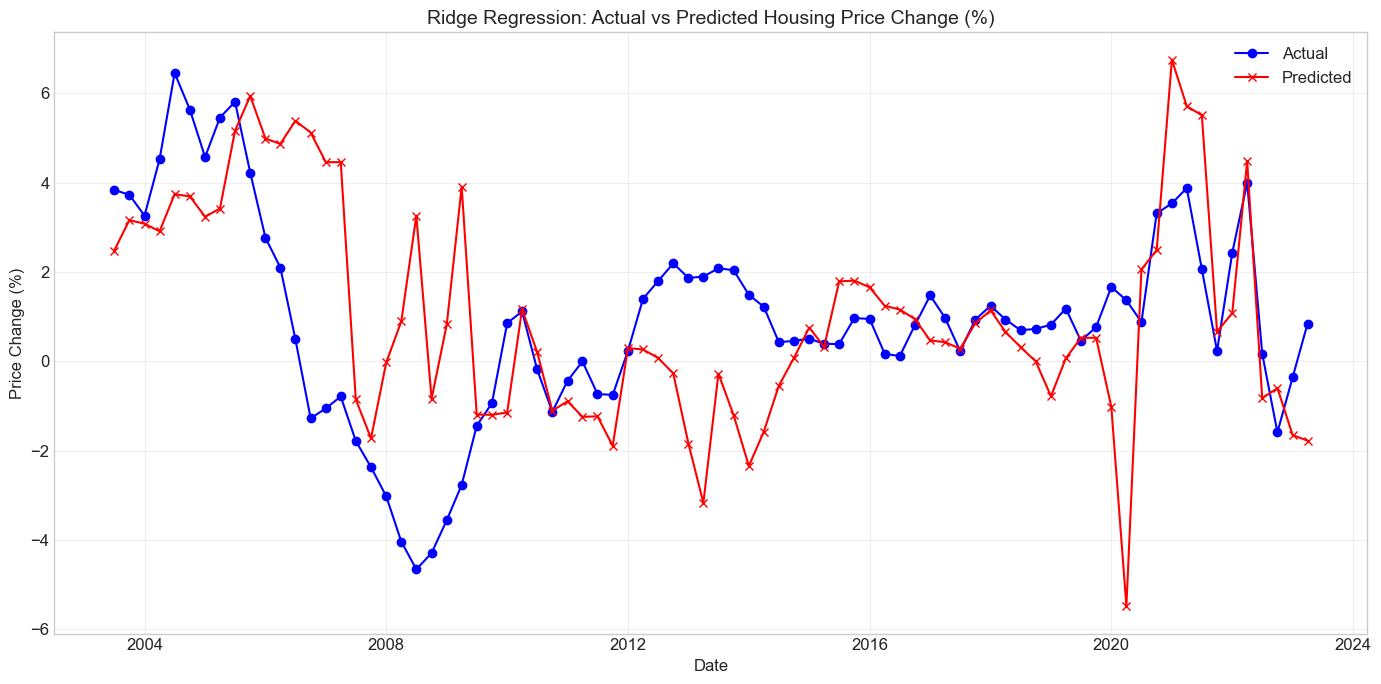

In [8]:
# Step 5: Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(results_base_ridge['Index'], results_base_ridge['Actual'], marker='o', label='Actual', color='blue')
plt.plot(results_base_ridge['Index'], results_base_ridge['Predicted'], marker='x', label='Predicted', color='red')
plt.title('Ridge Regression: Actual vs Predicted Housing Price Change (%)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Testing with 2 folds...
Folds: 2, Best alpha: 50.0, Best RMSE: 1.4972, Avg R²: -0.3172

Testing with 3 folds...
Folds: 3, Best alpha: 20.0, Best RMSE: 3.0392, Avg R²: -4.4427

Testing with 4 folds...
Folds: 4, Best alpha: 100.0, Best RMSE: 3.0646, Avg R²: -2.6292

Testing with 5 folds...
Folds: 5, Best alpha: 100.0, Best RMSE: 2.9499, Avg R²: -1.9502

Testing with 6 folds...
Folds: 6, Best alpha: 100.0, Best RMSE: 2.7091, Avg R²: -3.4880

Testing with 7 folds...
Folds: 7, Best alpha: 20.0, Best RMSE: 2.5754, Avg R²: -11.6285

===== OPTIMAL CONFIGURATION =====
Optimal number of folds: 2
Optimal alpha: 50.0
RMSE with optimal configuration: 1.4972
R² with optimal configuration: -0.3172


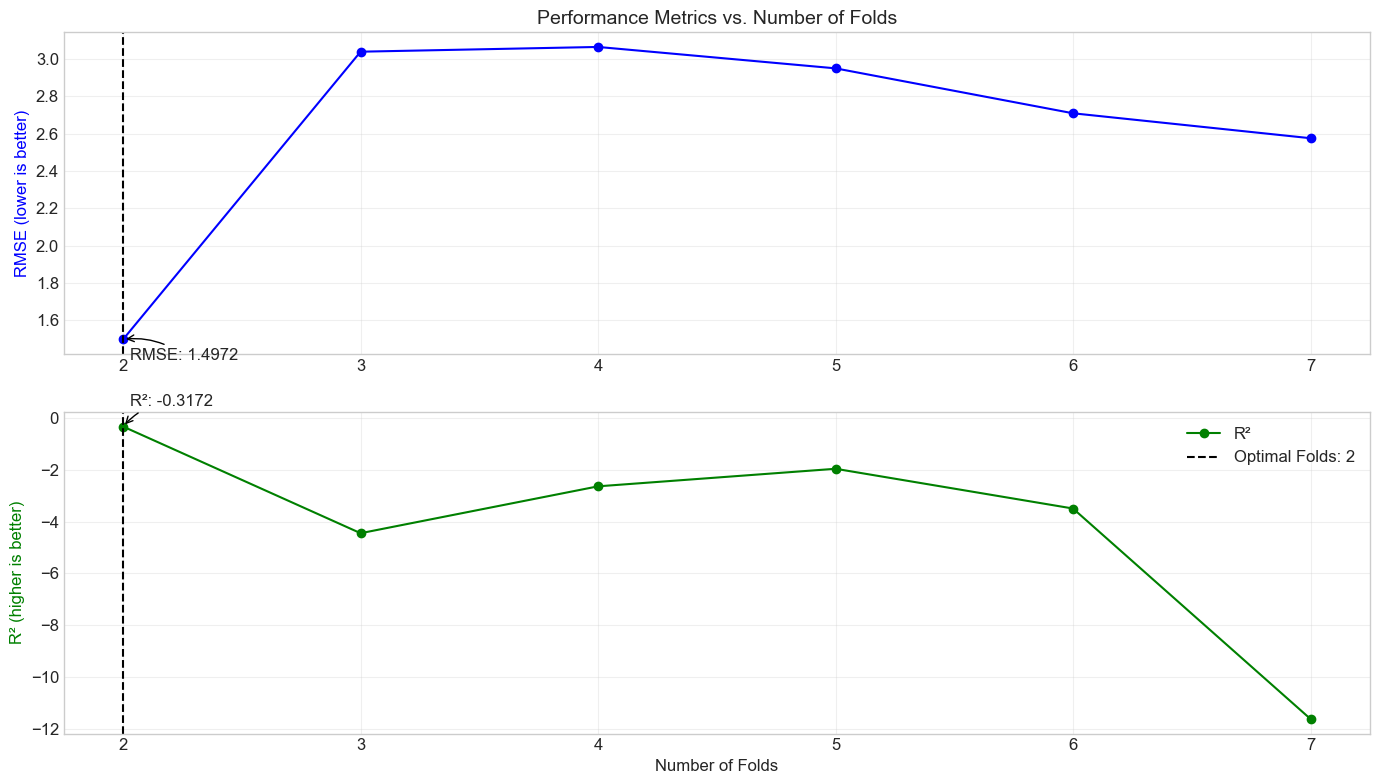

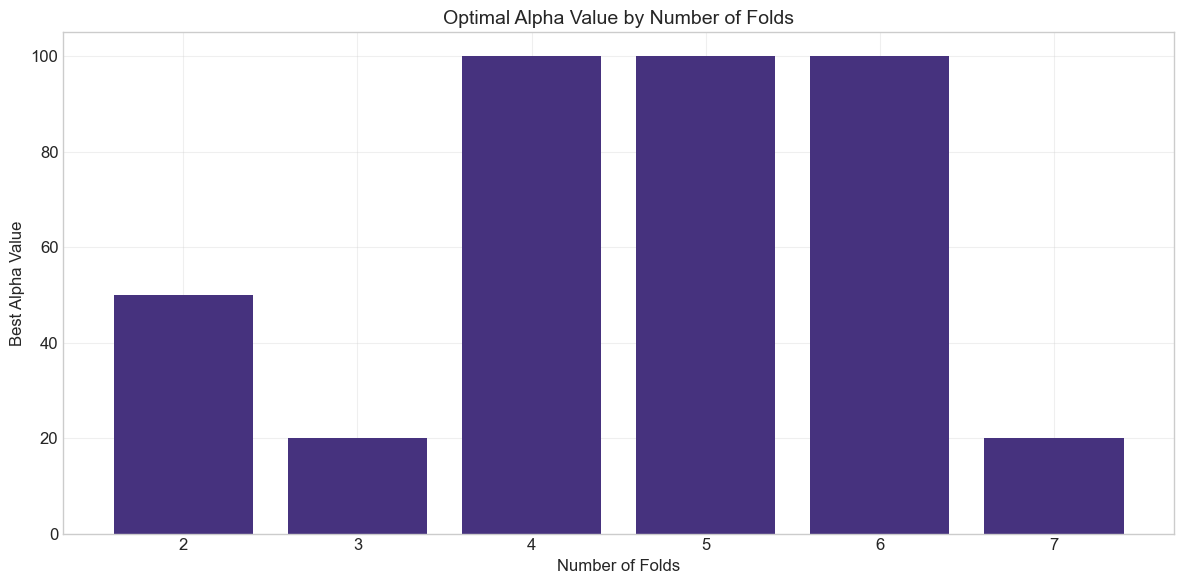


Detailed results for all fold counts:
   n_folds  best_alpha  best_rmse  avg_r2
0        2       50.00       1.50   -0.32
1        3       20.00       3.04   -4.44
2        4      100.00       3.06   -2.63
3        5      100.00       2.95   -1.95
4        6      100.00       2.71   -3.49
5        7       20.00       2.58  -11.63


In [41]:
# Step 6: Hyperparameter tuning with grid search for both alpha and number of folds
# Define parameter grid for Ridge regression
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0]
}

# Test different numbers of folds to find the optimal
fold_counts = [2, 3, 4, 5, 6, 7]
fold_results = []

for n_folds in fold_counts:
    print(f"\nTesting with {n_folds} folds...")
    
    # Create time series split for this fold count
    tscv_grid = TimeSeriesSplit(n_splits=n_folds)
    
    # Setup grid search
    grid_search = GridSearchCV(
        Ridge(), 
        param_grid, 
        cv=tscv_grid,
        scoring='neg_mean_squared_error',
        verbose=0,  # Set to 0 to reduce output clutter
        return_train_score=True
    )
    
    # Fit grid search
    grid_search.fit(X_scaled, y)
    
    # Get best alpha and score for this fold count
    best_alpha = grid_search.best_params_['alpha']
    best_score = grid_search.best_score_
    best_rmse = np.sqrt(-best_score)
    
    # Calculate R² for this configuration
    # We'll need to manually compute average R² across folds
    r2_scores = []
    for train_idx, test_idx in tscv_grid.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = Ridge(alpha=best_alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
    
    avg_r2 = np.mean(r2_scores)
    
    # Store results
    fold_results.append({
        'n_folds': n_folds,
        'best_alpha': best_alpha,
        'best_rmse': best_rmse,
        'avg_r2': avg_r2
    })
    
    print(f"Folds: {n_folds}, Best alpha: {best_alpha}, Best RMSE: {best_rmse:.4f}, Avg R²: {avg_r2:.4f}")

# Convert results to DataFrame
fold_results_df = pd.DataFrame(fold_results)

# Find the optimal combination
optimal_idx = fold_results_df['avg_r2'].idxmax()  # Use R² to find optimal (higher is better)
optimal_folds = fold_results_df.loc[optimal_idx, 'n_folds']
optimal_alpha = fold_results_df.loc[optimal_idx, 'best_alpha']

print("\n===== OPTIMAL CONFIGURATION =====")
print(f"Optimal number of folds: {optimal_folds}")
print(f"Optimal alpha: {optimal_alpha}")
print(f"RMSE with optimal configuration: {fold_results_df.loc[optimal_idx, 'best_rmse']:.4f}")
print(f"R² with optimal configuration: {fold_results_df.loc[optimal_idx, 'avg_r2']:.4f}")

# Plot the results to visualize the trade-offs
plt.figure(figsize=(14, 8))

# Create a subplot for RMSE
ax1 = plt.subplot(2, 1, 1)
ax1.plot(fold_results_df['n_folds'], fold_results_df['best_rmse'], 'o-', color='blue', label='RMSE')
ax1.set_ylabel('RMSE (lower is better)', color='blue')
ax1.axvline(x=optimal_folds, color='black', linestyle='--')
ax1.grid(True, alpha=0.3)
ax1.set_title('Performance Metrics vs. Number of Folds', fontsize=14)

# Create a subplot for R²
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(fold_results_df['n_folds'], fold_results_df['avg_r2'], 'o-', color='green', label='R²')
ax2.set_ylabel('R² (higher is better)', color='green')
ax2.axvline(x=optimal_folds, color='black', linestyle='--', label=f'Optimal Folds: {optimal_folds}')
ax2.set_xlabel('Number of Folds')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Annotate optimal points
ax1.annotate(f'RMSE: {fold_results_df.loc[optimal_idx, "best_rmse"]:.4f}', 
            xy=(optimal_folds, fold_results_df.loc[optimal_idx, 'best_rmse']),
            xytext=(5, -15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

ax2.annotate(f'R²: {fold_results_df.loc[optimal_idx, "avg_r2"]:.4f}', 
            xy=(optimal_folds, fold_results_df.loc[optimal_idx, 'avg_r2']),
            xytext=(5, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2'))

plt.tight_layout()
plt.show()

# Also show the alpha values selected for each fold count
plt.figure(figsize=(12, 6))
plt.bar(fold_results_df['n_folds'].astype(str), fold_results_df['best_alpha'])
plt.title('Optimal Alpha Value by Number of Folds', fontsize=14)
plt.xlabel('Number of Folds')
plt.ylabel('Best Alpha Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a table for detailed results
print("\nDetailed results for all fold counts:")
print(fold_results_df[['n_folds', 'best_alpha', 'best_rmse', 'avg_r2']])

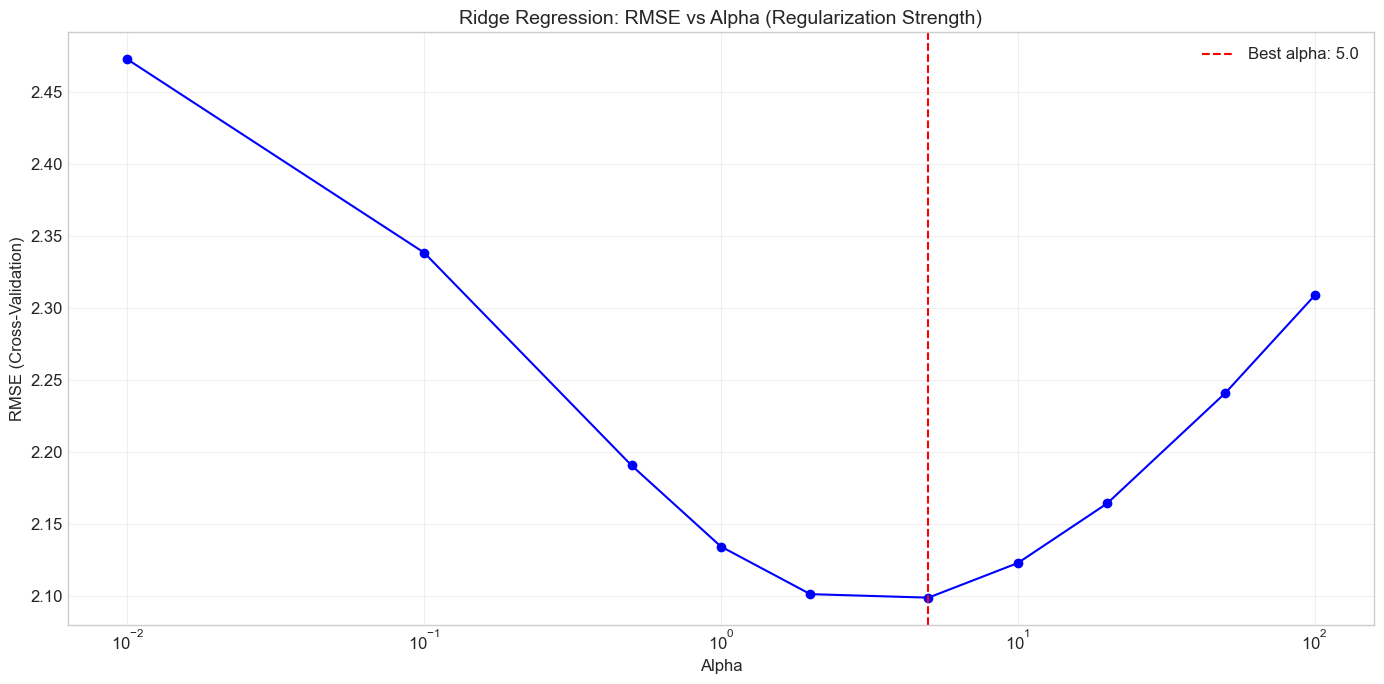

In [34]:
# Step 7: Plot cross-validation results for different alpha values
plt.figure(figsize=(14, 7))
alphas = param_grid['alpha']
cv_results = grid_search.cv_results_

# Extract test scores
test_scores = np.sqrt(-cv_results['mean_test_score'])

# Plot alpha vs RMSE curve
plt.semilogx(alphas, test_scores, marker='o', linestyle='-', color='blue')
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Best alpha: {best_alpha}')
plt.title('Ridge Regression: RMSE vs Alpha (Regularization Strength)', fontsize=14)
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('RMSE (Cross-Validation)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



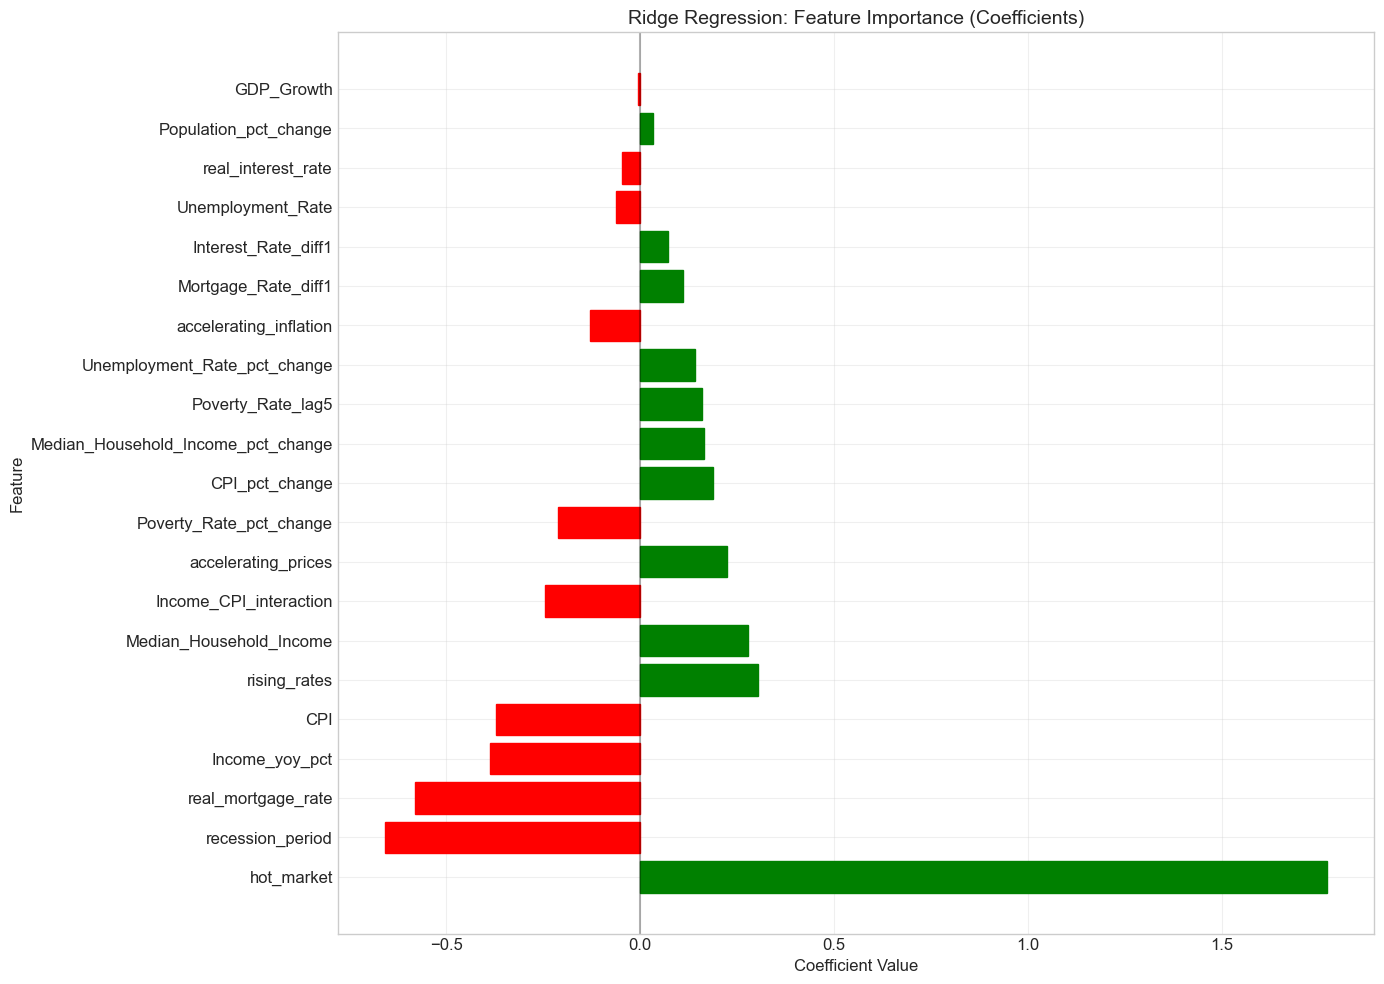


Final Ridge Model (with best alpha) Full Dataset Performance:
RMSE: 0.97
MAE: 0.76
R²: 0.812


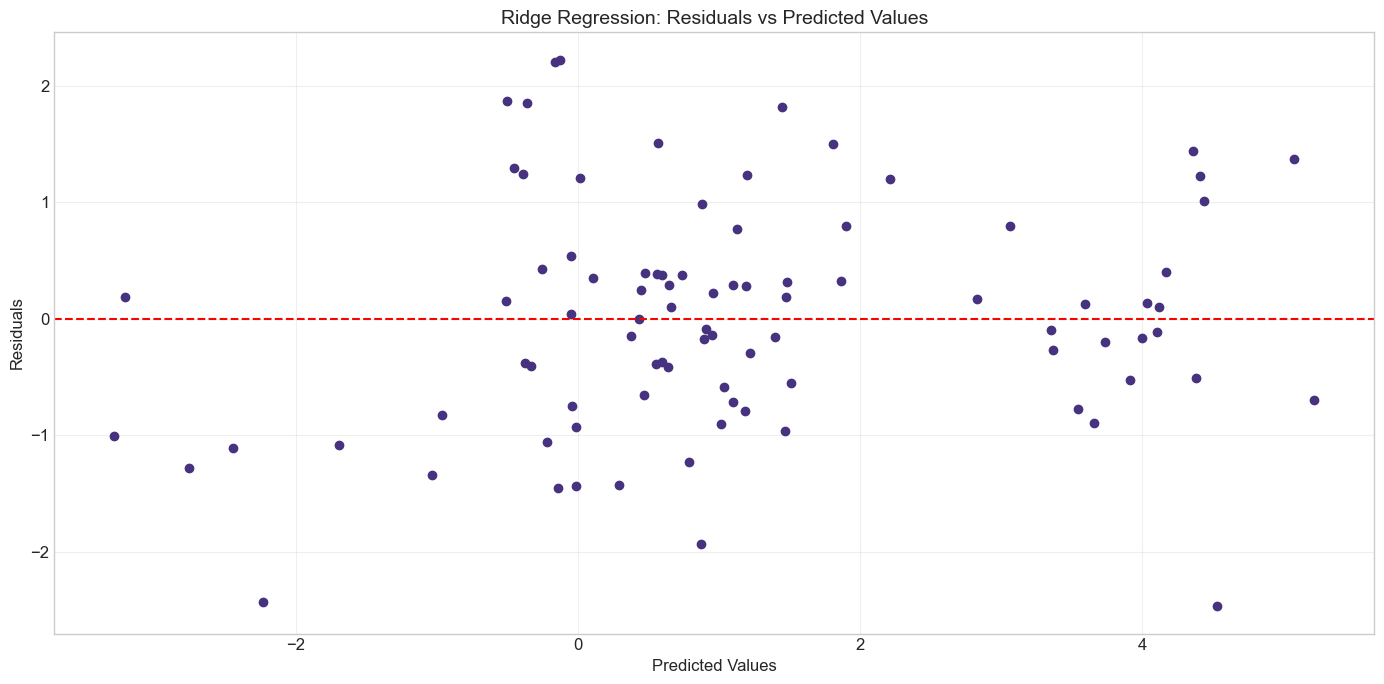

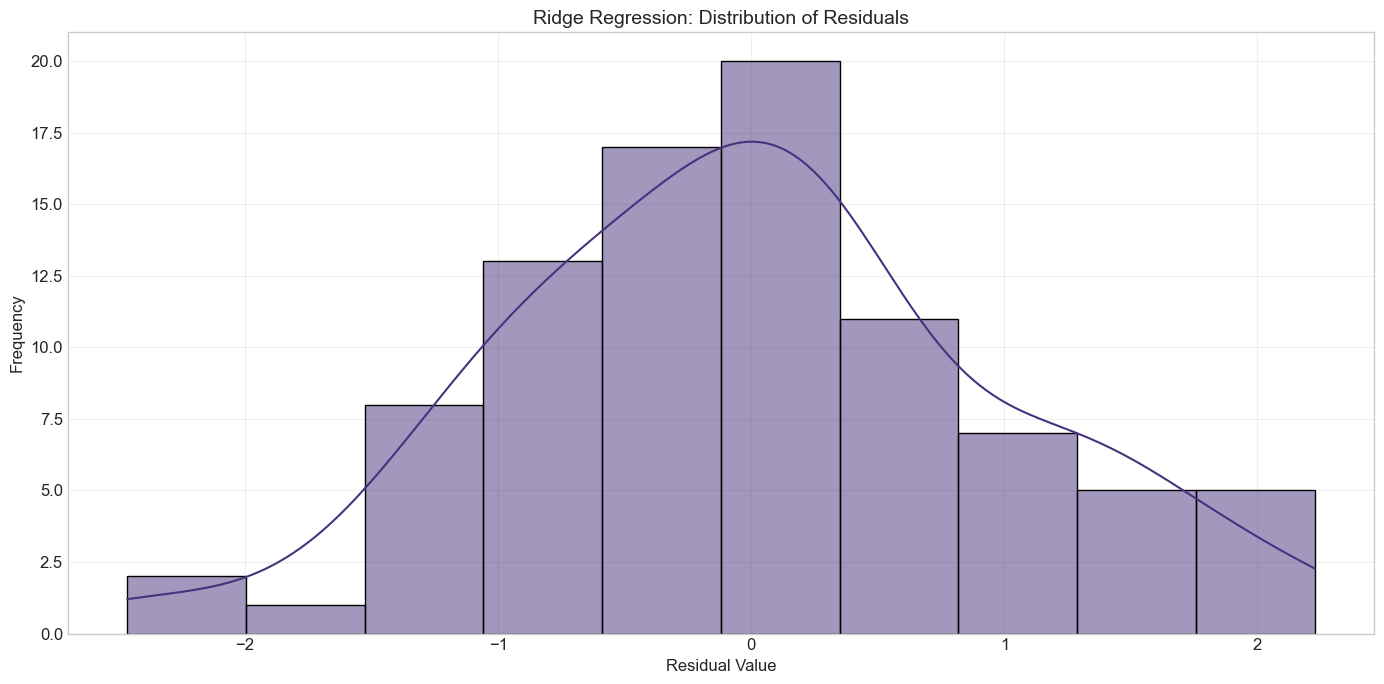

<Figure size 1400x700 with 0 Axes>

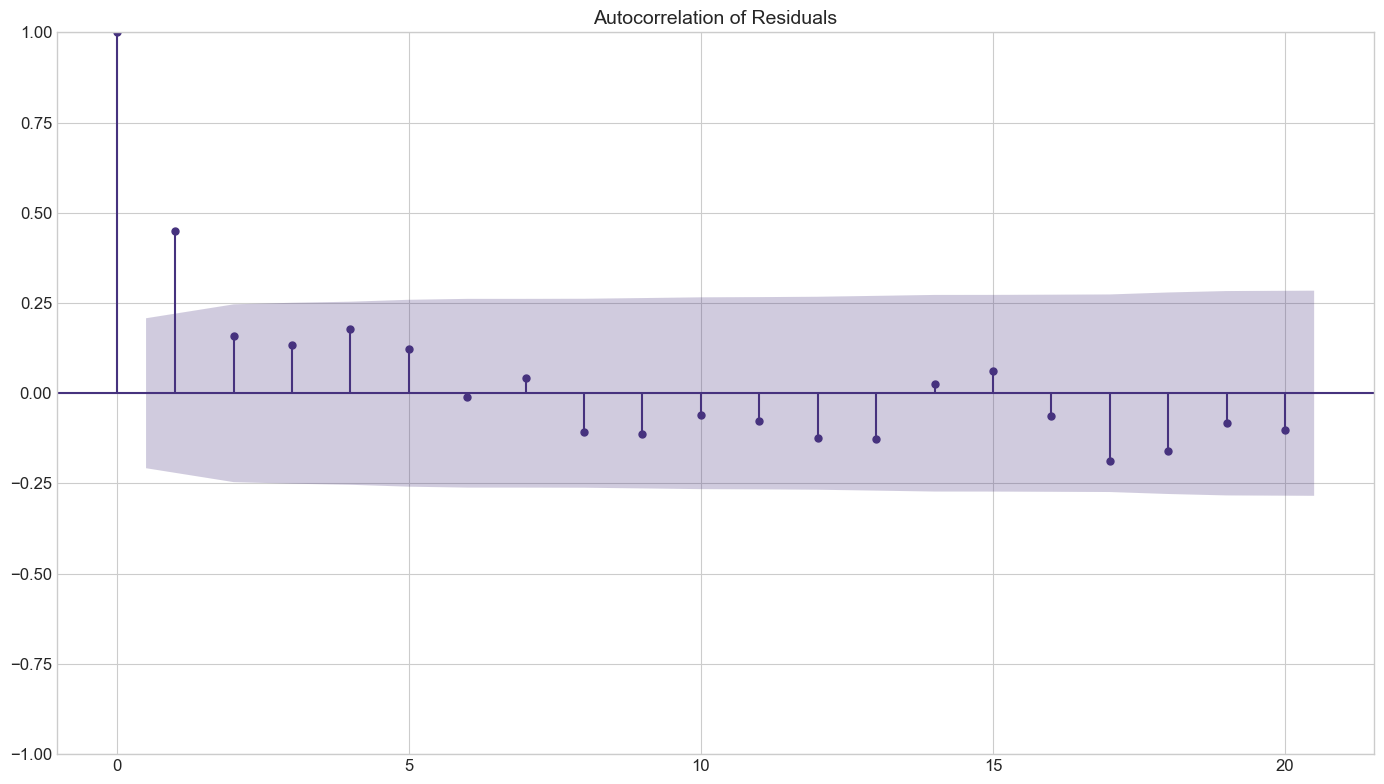

In [35]:
# Step 8: Train final model with best alpha
final_ridge = Ridge(alpha=best_alpha)
final_ridge.fit(X_scaled, y)

# Step 9: Analyze feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_ridge.coef_,
    'Abs_Coefficient': np.abs(final_ridge.coef_)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(14, 10))
bars = plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

# Color the bars based on the sign of the coefficient
for i, bar in enumerate(bars):
    if feature_importance.iloc[i]['Coefficient'] < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

plt.title('Ridge Regression: Feature Importance (Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 10: Evaluate final model performance
# Train the final model on all data
final_ridge.fit(X_scaled, y)
y_pred_full = final_ridge.predict(X_scaled)

# Calculate metrics
rmse_full = np.sqrt(mean_squared_error(y, y_pred_full))
mae_full = mean_absolute_error(y, y_pred_full)
r2_full = r2_score(y, y_pred_full)

print("\nFinal Ridge Model (with best alpha) Full Dataset Performance:")
print(f"RMSE: {rmse_full:.2f}")
print(f"MAE: {mae_full:.2f}")
print(f"R²: {r2_full:.3f}")

# Step 11: Plot residuals
residuals = y - y_pred_full
plt.figure(figsize=(14, 7))
plt.scatter(y_pred_full, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Ridge Regression: Residuals vs Predicted Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 12: Plot residual distribution
plt.figure(figsize=(14, 7))
sns.histplot(residuals, kde=True)
plt.title('Ridge Regression: Distribution of Residuals', fontsize=14)
plt.xlabel('Residual Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 13: Check for autocorrelation in residuals
plt.figure(figsize=(14, 7))
plot_acf(residuals, lags=20, alpha=0.05)
plt.title('Autocorrelation of Residuals', fontsize=14)
plt.tight_layout()
plt.show()

Understanding in-sample vs. out-of-sample performance:
----------------------------------------------------------------------
In-sample performance (fitting and evaluating on all data):
RMSE: 0.97, R²: 0.8119
Note: This typically looks good but doesn't represent real predictive power



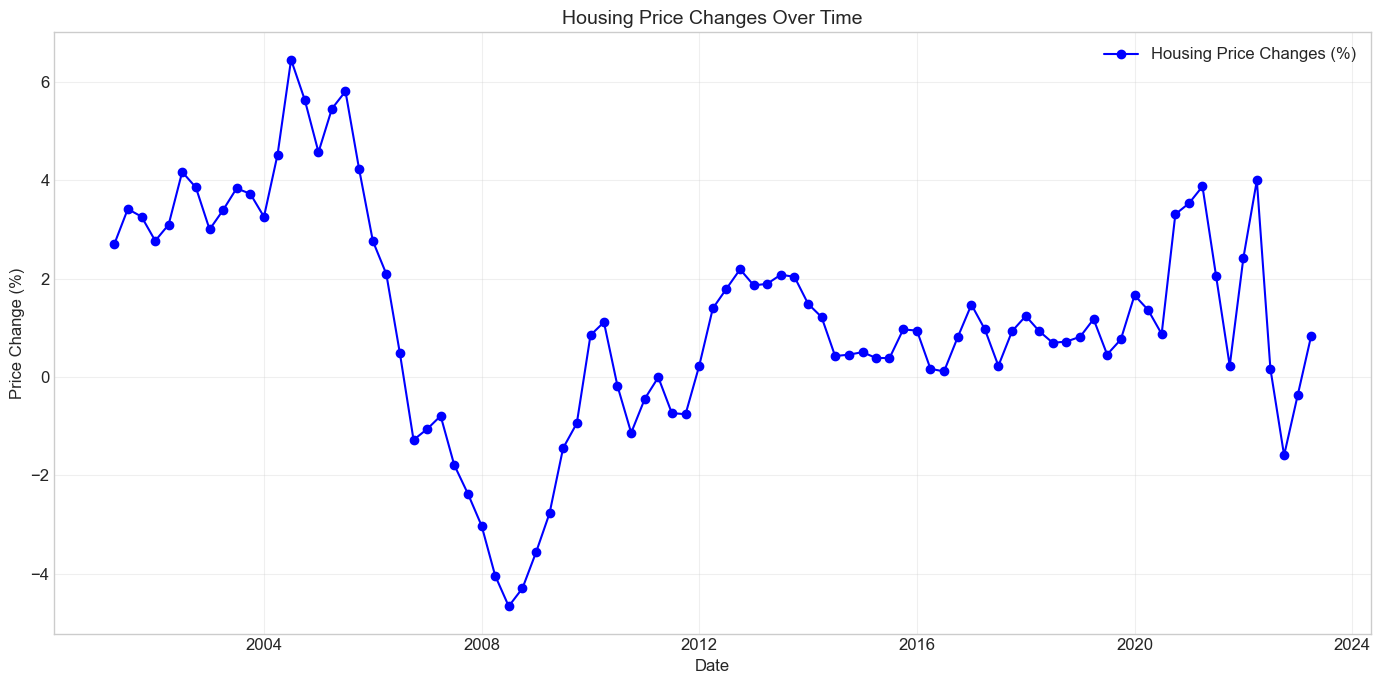

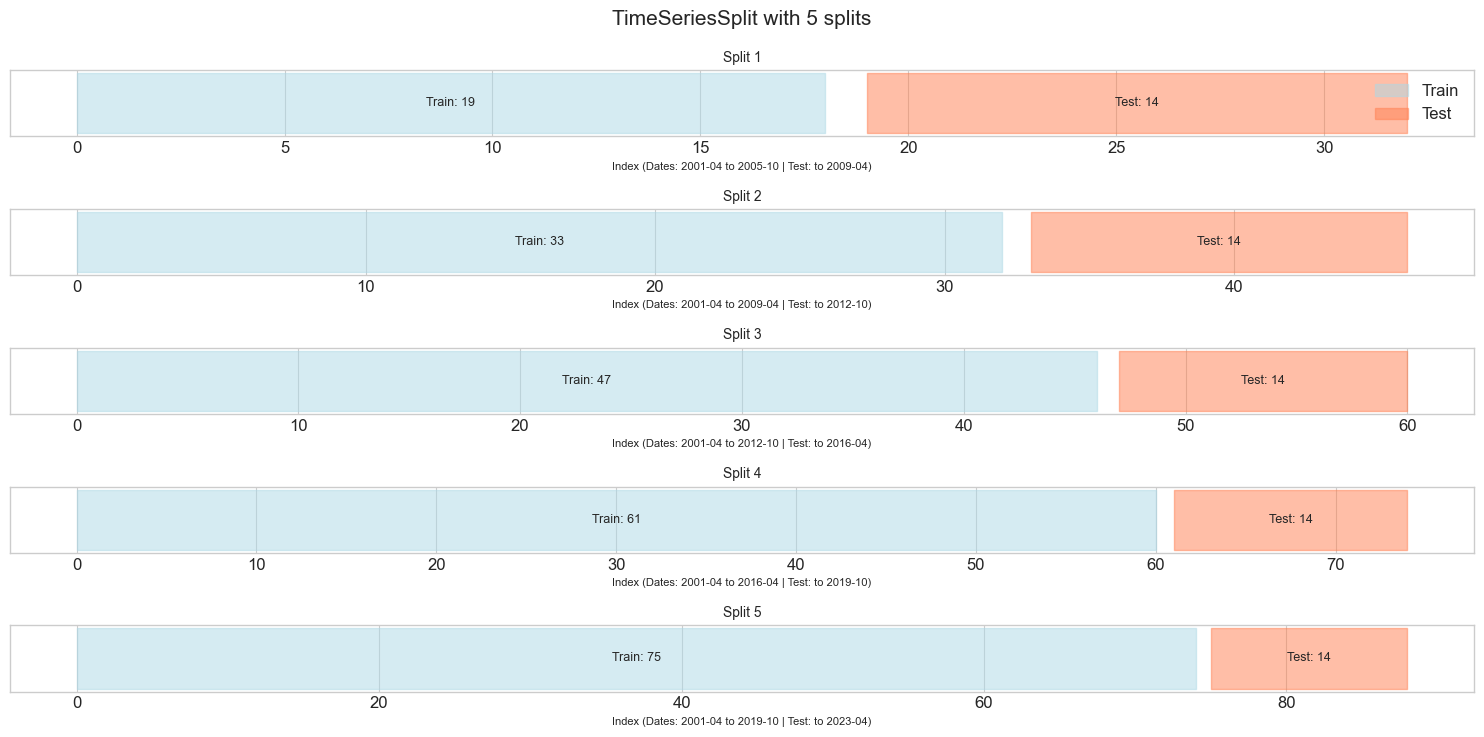

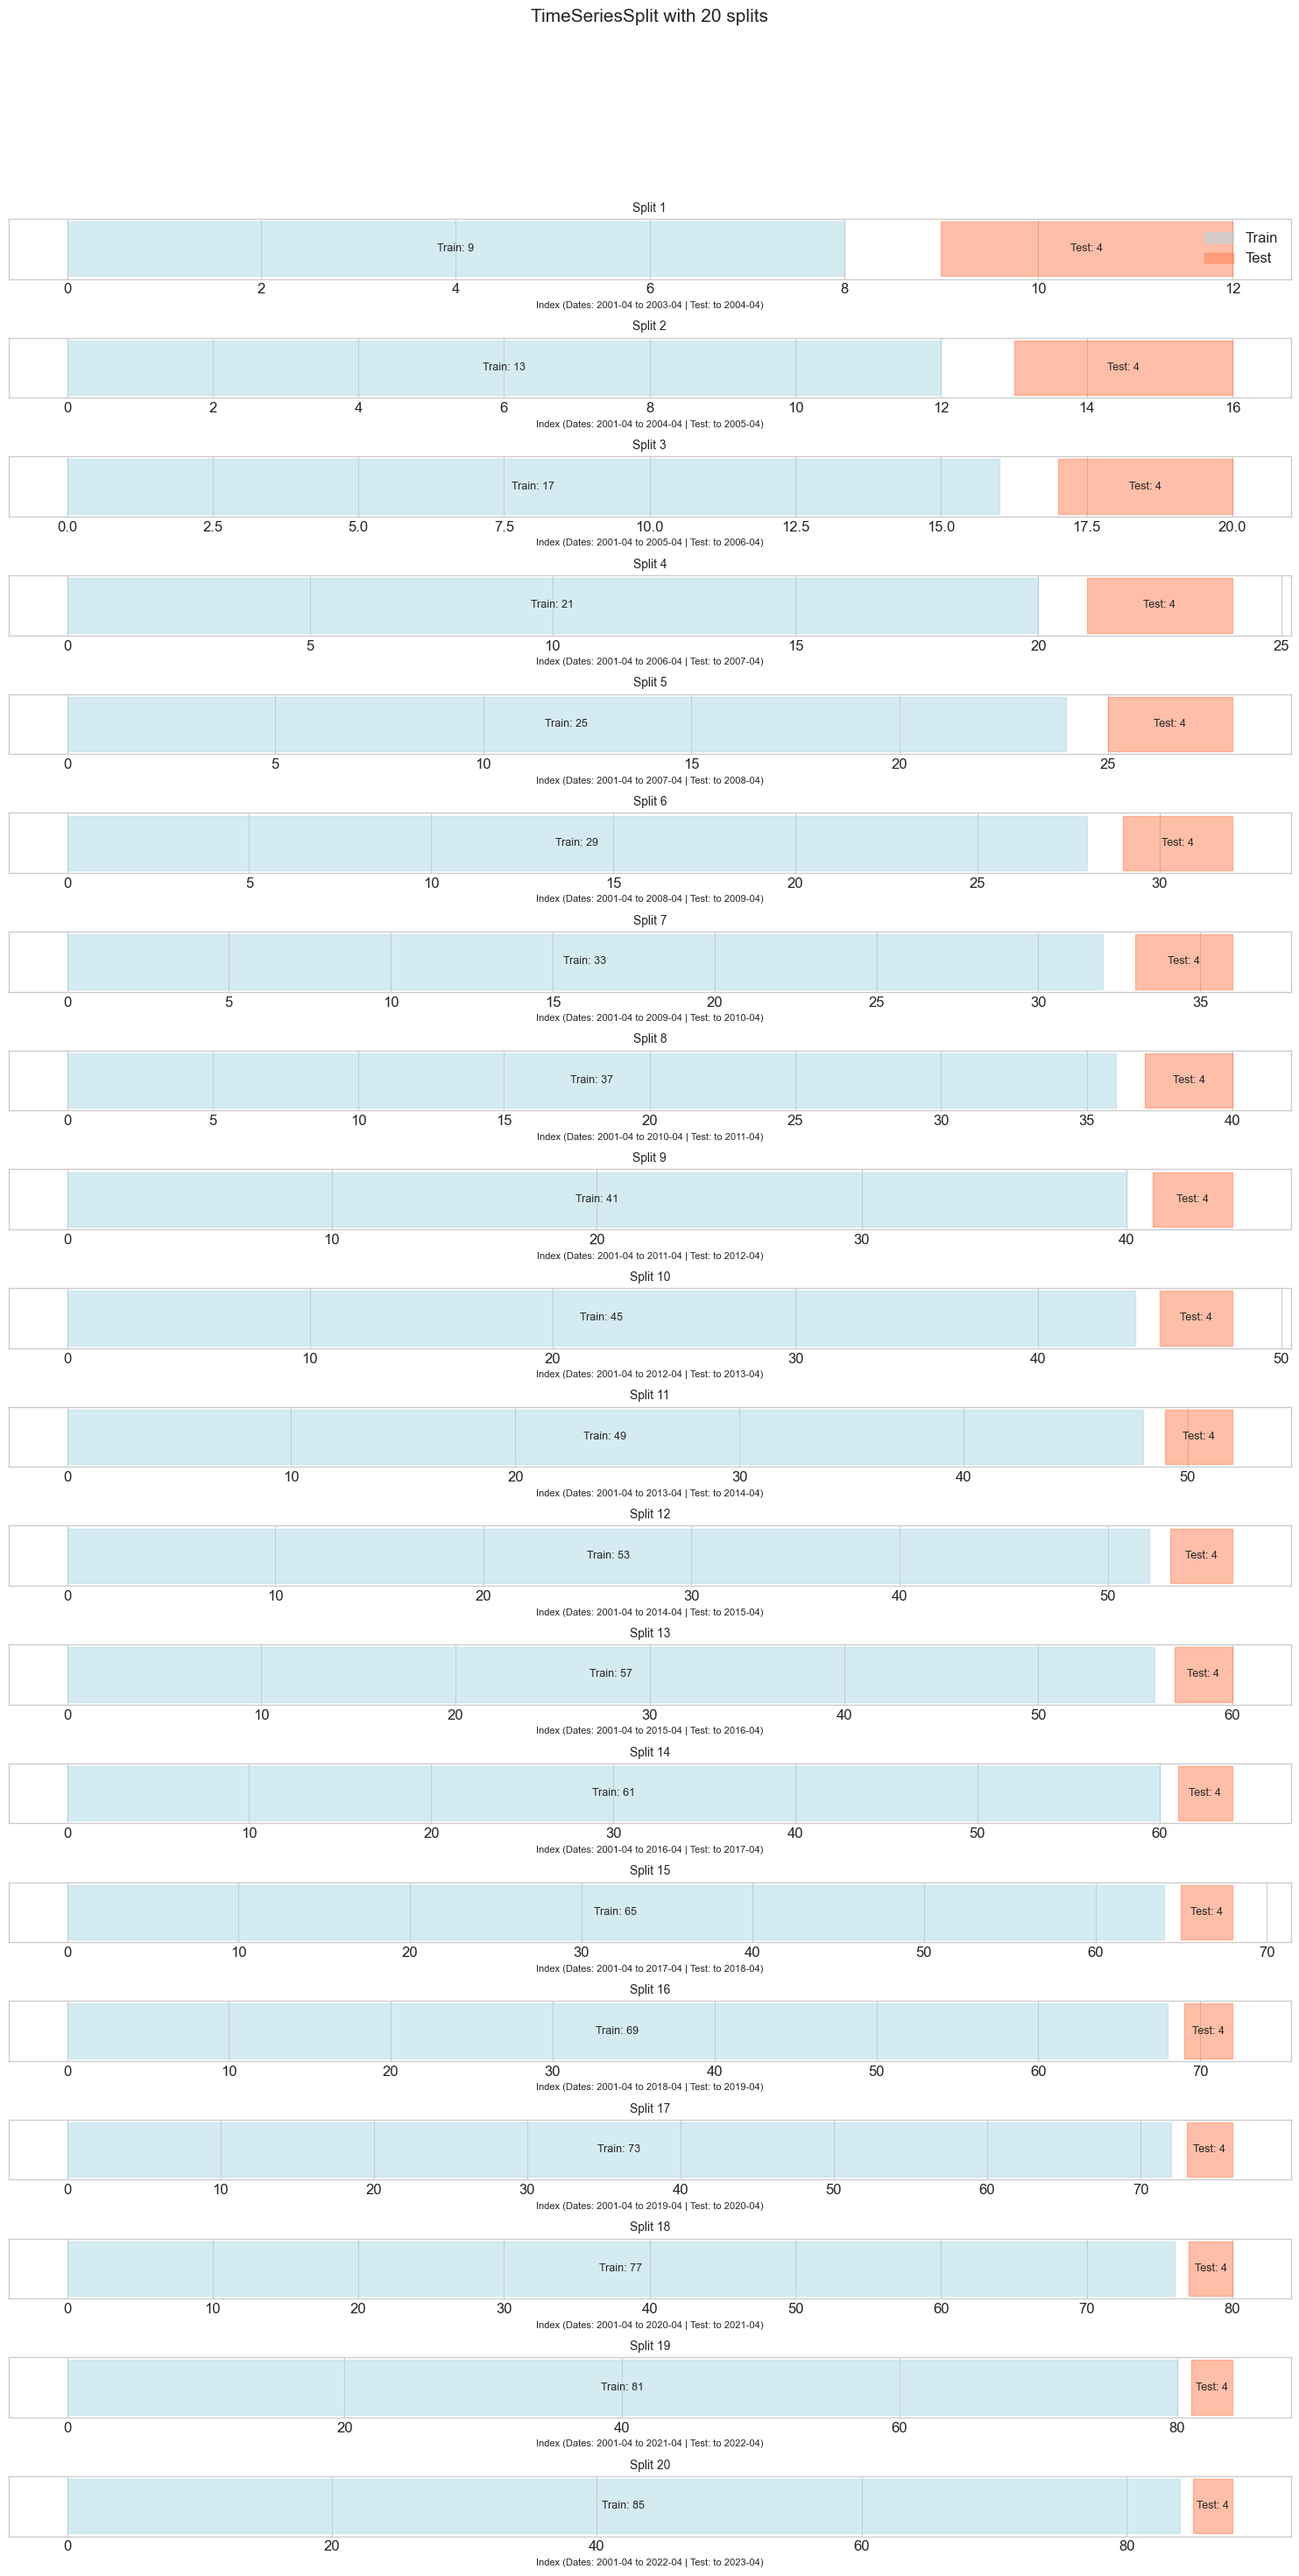


Created 6 custom splits with minimum training size of 63
Alpha:    0.01, Avg R²: -5.1079 (±4.6732), Avg RMSE: 1.8122 (±1.3495)
Alpha:    0.10, Avg R²: -5.1340 (±4.5921), Avg RMSE: 1.8125 (±1.3581)
Alpha:    0.50, Avg R²: -5.5754 (±4.8065), Avg RMSE: 1.8263 (±1.3599)
Alpha:    1.00, Avg R²: -6.1441 (±5.3599), Avg RMSE: 1.8392 (±1.3509)
Alpha:    2.00, Avg R²: -6.8643 (±6.3835), Avg RMSE: 1.8397 (±1.3390)
Alpha:    5.00, Avg R²: -7.3130 (±7.7399), Avg RMSE: 1.7752 (±1.3195)
Alpha:   10.00, Avg R²: -6.7440 (±7.8827), Avg RMSE: 1.6572 (±1.2829)
Alpha:   20.00, Avg R²: -5.4741 (±7.0316), Avg RMSE: 1.4906 (±1.2137)
Alpha:   50.00, Avg R²: -3.3584 (±4.9585), Avg RMSE: 1.2671 (±1.0606)
Alpha:  100.00, Avg R²: -1.8616 (±3.2627), Avg RMSE: 1.1556 (±0.9075)

Best alpha from custom CV: 100.0
Best average R²: -1.8616
RMSE with best alpha: 1.1556


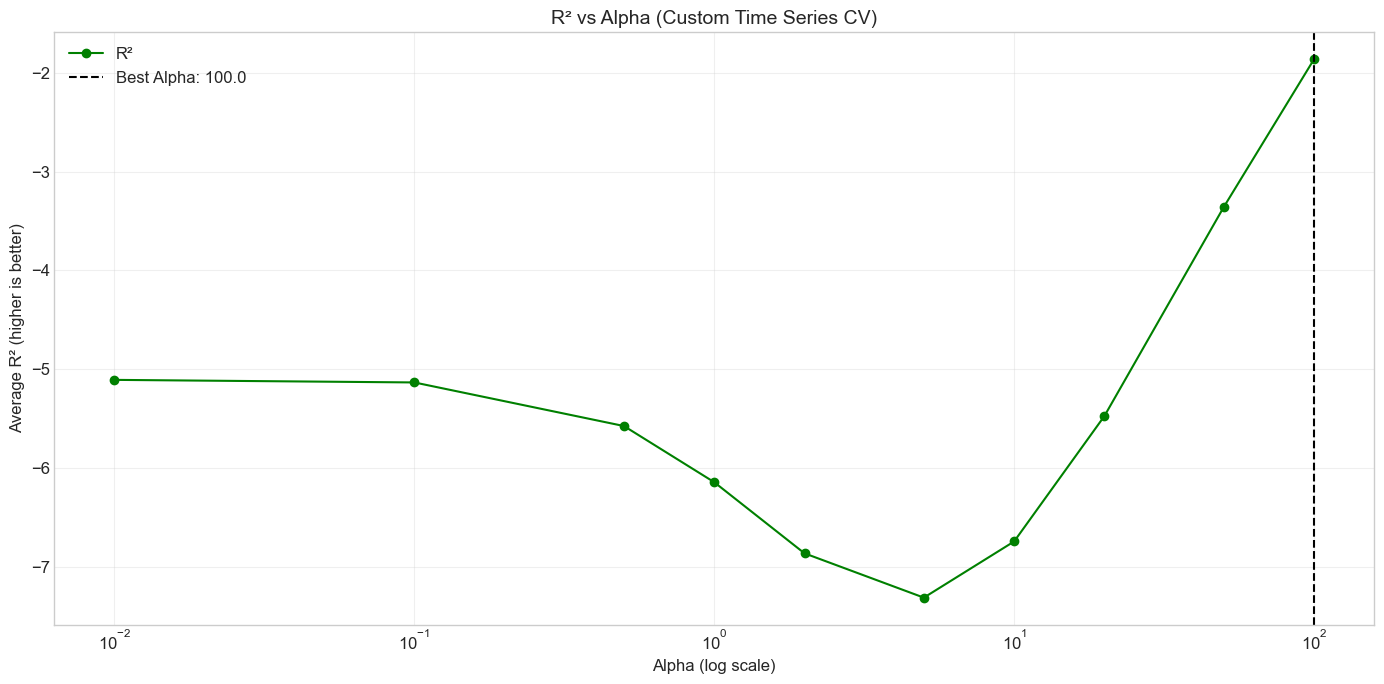

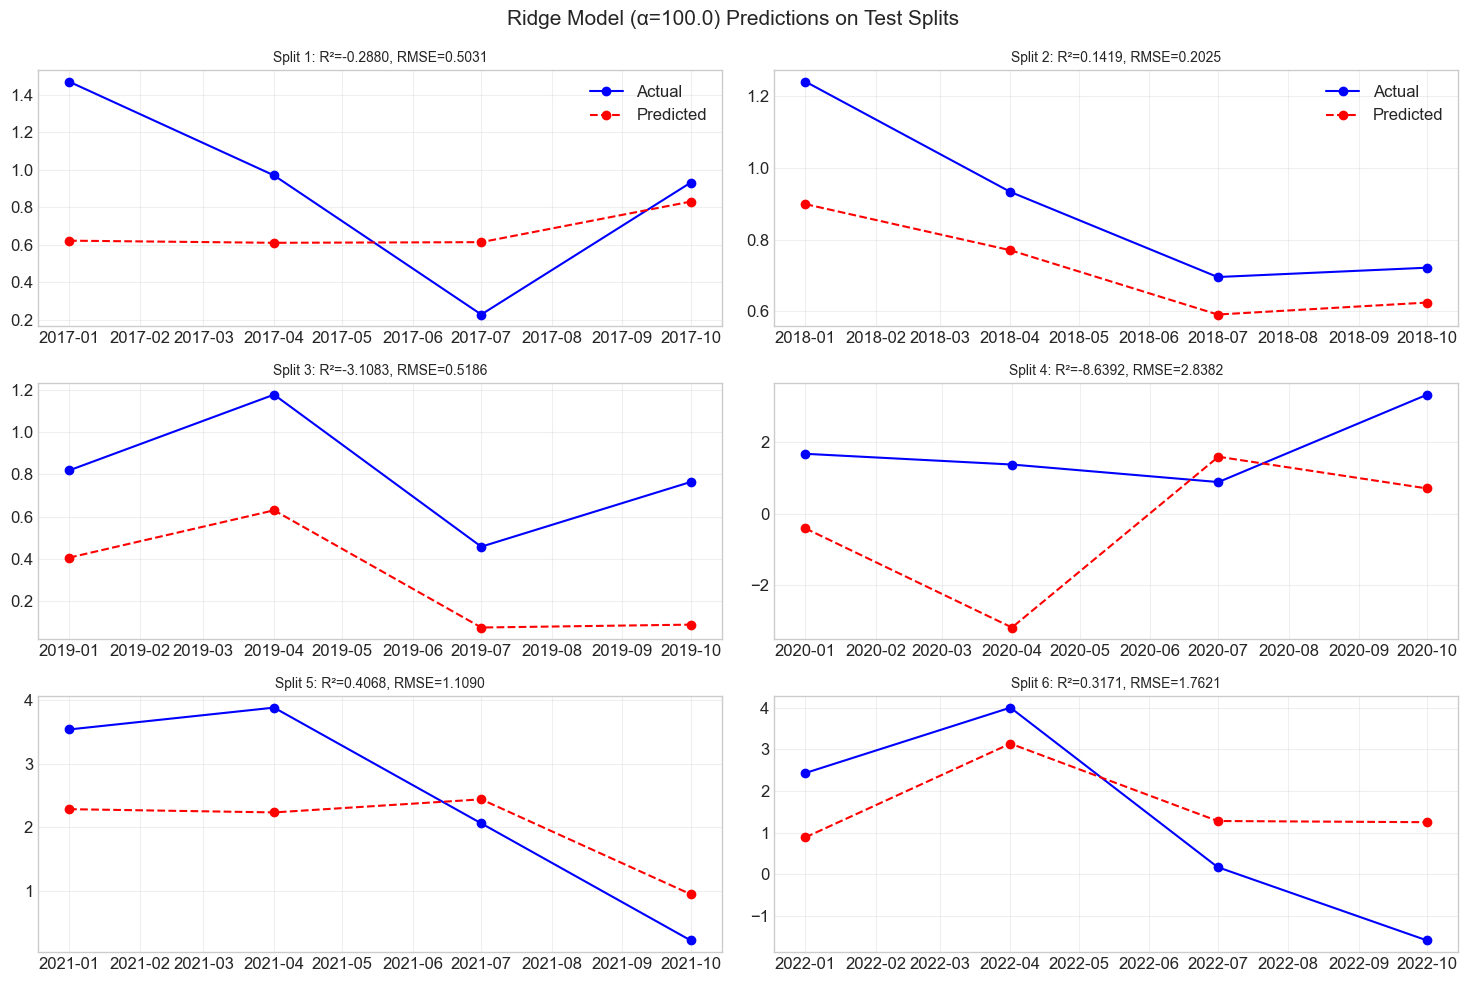

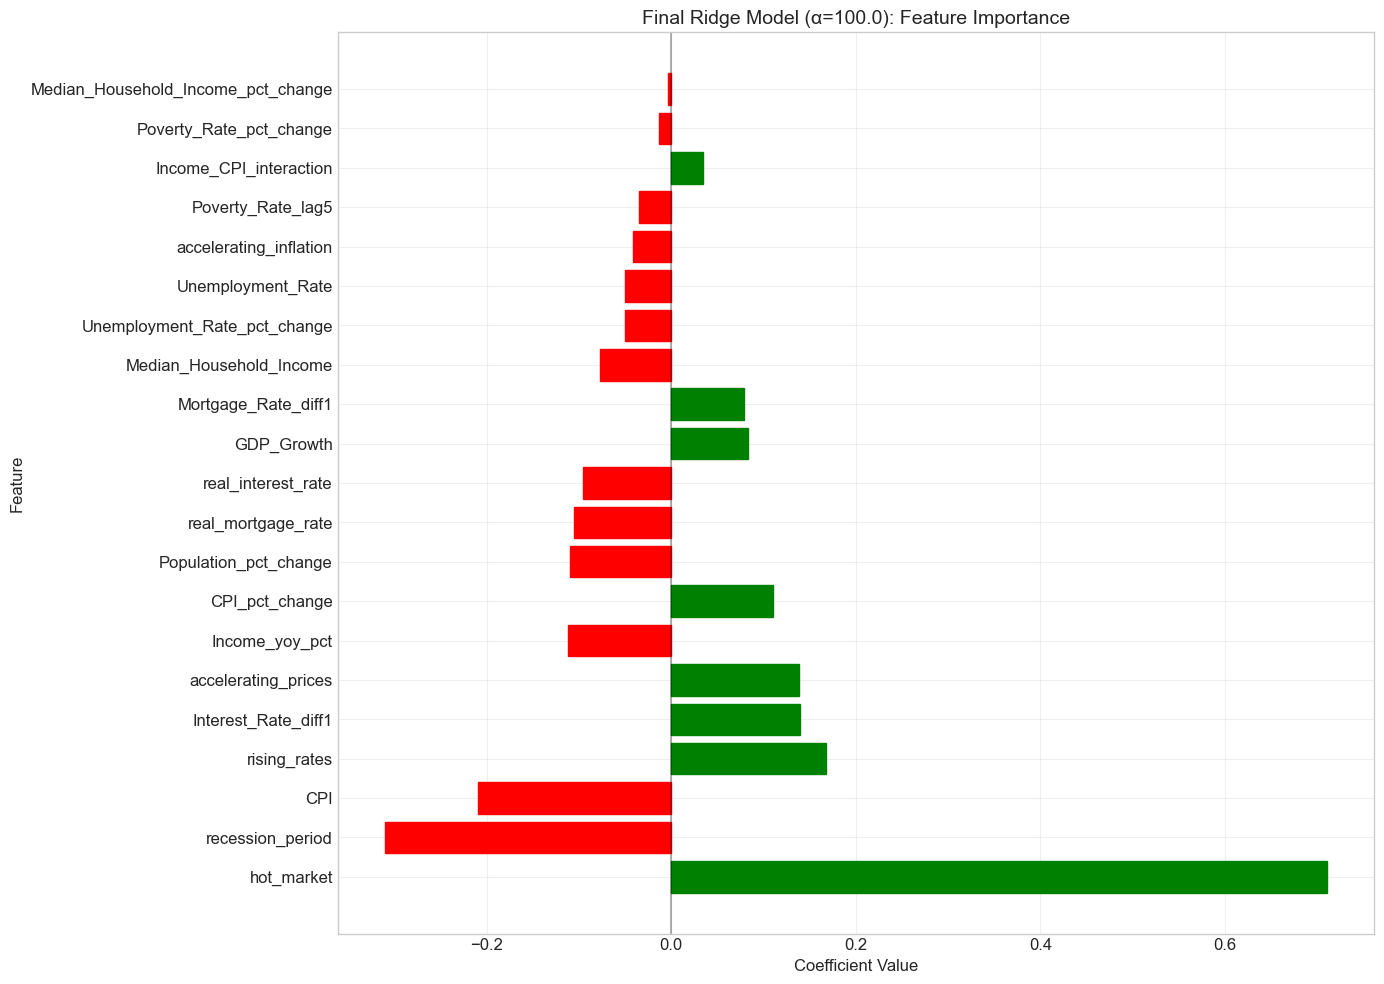

In [37]:
# Improved analysis to understand the discrepancy in R² values

# First, let's show the difference between in-sample and out-of-sample performance
print("Understanding in-sample vs. out-of-sample performance:")
print("-"*70)

# Use a fixed alpha value that worked well before
alpha_value = 5.0

# In-sample performance (training and testing on same data)
model_in_sample = Ridge(alpha=alpha_value)
model_in_sample.fit(X_scaled, y)
y_pred_in_sample = model_in_sample.predict(X_scaled)

# Calculate in-sample metrics
rmse_in = np.sqrt(mean_squared_error(y, y_pred_in_sample))
r2_in = r2_score(y, y_pred_in_sample)

print(f"In-sample performance (fitting and evaluating on all data):")
print(f"RMSE: {rmse_in:.2f}, R²: {r2_in:.4f}")
print("Note: This typically looks good but doesn't represent real predictive power\n")

# Visualize the data to understand the challenge better
plt.figure(figsize=(14, 7))
plt.plot(y.index, y, 'o-', label='Housing Price Changes (%)', color='blue')
plt.title('Housing Price Changes Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Function to visualize cross-validation splits
def plot_ts_cv_splits(X, n_splits):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    plt.figure(figsize=(15, n_splits*1.5))
    plt.suptitle(f'TimeSeriesSplit with {n_splits} splits', fontsize=15)
    
    for i, (train_index, test_index) in enumerate(tscv.split(X)):
        # Plot the training set
        train_start_idx = np.min(train_index)
        train_end_idx = np.max(train_index)
        
        # Plot the test set
        test_start_idx = np.min(test_index)
        test_end_idx = np.max(test_index)
        
        # Create the plot
        plt.subplot(n_splits, 1, i+1)
        plt.fill_between([train_start_idx, train_end_idx], 0, 1, color='lightblue', alpha=0.5, label='Train')
        plt.fill_between([test_start_idx, test_end_idx], 0, 1, color='coral', alpha=0.5, label='Test')
        
        # Format
        if i == 0:
            plt.legend(loc='center right')
        plt.yticks([])
        plt.title(f'Split {i+1}', fontsize=10)
        
        # Add text with train/test sizes
        train_size = len(train_index)
        test_size = len(test_index)
        plt.text(train_start_idx + (train_end_idx - train_start_idx)/2, 0.5, f'Train: {train_size}', 
                ha='center', va='center', fontsize=9)
        plt.text(test_start_idx + (test_end_idx - test_start_idx)/2, 0.5, f'Test: {test_size}', 
                ha='center', va='center', fontsize=9)
        
        # Add date ranges
        date_start = X.index[train_start_idx].strftime('%Y-%m')
        date_mid = X.index[train_end_idx].strftime('%Y-%m')
        date_end = X.index[test_end_idx].strftime('%Y-%m')
        
        plt.xlabel(f'Index (Dates: {date_start} to {date_mid} | Test: to {date_end})', fontsize=8)
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Visualize splits with different fold counts
plot_ts_cv_splits(X_scaled_df, n_splits=5)  # Try with 5 splits
plot_ts_cv_splits(X_scaled_df, n_splits=20)  # Try with 20 splits

# Now let's implement a more robust approach:
# 1. Use a minimum number of samples for training
# 2. Progressively increase the test size
# 3. Start from a reasonable point in the time series

# Define the minimum training size (adjust based on feature count)
min_train_size = len(X.columns) * 3  # Rule of thumb: at least 3 samples per feature

# Create custom splits that ensure adequate training data
def custom_ts_cv(X, min_train_size, max_splits=15):
    n = len(X)
    splits = []
    
    # Calculate reasonable minimum test size
    min_test_size = max(2, int(n * 0.05))  # At least 2 samples or 5% of data
    
    # Determine how many splits we can have
    remaining_samples = n - min_train_size
    if remaining_samples < min_test_size:
        print(f"Warning: Not enough data for reliable cv with min_train_size={min_train_size}")
        max_splits = 1
    
    # Create splits
    actual_splits = min(max_splits, remaining_samples // min_test_size)
    test_size = remaining_samples // actual_splits
    
    for i in range(actual_splits):
        train_end = min_train_size + i * test_size
        test_start = train_end
        test_end = min(n, test_start + test_size)
        
        train_indices = np.arange(0, train_end)
        test_indices = np.arange(test_start, test_end)
        
        splits.append((train_indices, test_indices))
        
        if test_end >= n:
            break
            
    return splits

# Create custom splits
custom_splits = custom_ts_cv(X_scaled_df, min_train_size=min_train_size)
n_custom_splits = len(custom_splits)

print(f"\nCreated {n_custom_splits} custom splits with minimum training size of {min_train_size}")

# Test different alphas with the custom splits
alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
alpha_results = []

for alpha in alphas:
    cv_r2_scores = []
    cv_rmse_scores = []
    
    for train_idx, test_idx in custom_splits:
        X_train, X_test = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        cv_r2_scores.append(r2_score(y_test, y_pred))
        cv_rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    
    avg_r2 = np.mean(cv_r2_scores)
    avg_rmse = np.mean(cv_rmse_scores)
    
    alpha_results.append({
        'alpha': alpha,
        'avg_r2': avg_r2,
        'avg_rmse': avg_rmse,
        'r2_std': np.std(cv_r2_scores),
        'rmse_std': np.std(cv_rmse_scores)
    })
    
    print(f"Alpha: {alpha:7.2f}, Avg R²: {avg_r2:.4f} (±{np.std(cv_r2_scores):.4f}), "
          f"Avg RMSE: {avg_rmse:.4f} (±{np.std(cv_rmse_scores):.4f})")

# Convert to DataFrame
alpha_results_df = pd.DataFrame(alpha_results)

# Find the optimal alpha
best_alpha_idx = alpha_results_df['avg_r2'].idxmax()
best_alpha = alpha_results_df.loc[best_alpha_idx, 'alpha']

print(f"\nBest alpha from custom CV: {best_alpha}")
print(f"Best average R²: {alpha_results_df.loc[best_alpha_idx, 'avg_r2']:.4f}")
print(f"RMSE with best alpha: {alpha_results_df.loc[best_alpha_idx, 'avg_rmse']:.4f}")

# Plot the results
plt.figure(figsize=(14, 7))
plt.semilogx(alpha_results_df['alpha'], alpha_results_df['avg_r2'], 'o-', color='green', label='R²')
plt.axvline(x=best_alpha, color='black', linestyle='--', label=f'Best Alpha: {best_alpha}')
plt.title('R² vs Alpha (Custom Time Series CV)', fontsize=14)
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Average R² (higher is better)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final model predictions on each split
plt.figure(figsize=(15, 10))
plt.suptitle(f'Ridge Model (α={best_alpha}) Predictions on Test Splits', fontsize=15)

final_model = Ridge(alpha=best_alpha)

for i, (train_idx, test_idx) in enumerate(custom_splits):
    X_train, X_test = X_scaled_df.iloc[train_idx], X_scaled_df.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    plt.subplot(int(np.ceil(n_custom_splits/2)), 2, i+1)
    plt.plot(y_test.index, y_test, 'o-', label='Actual', color='blue')
    plt.plot(y_test.index, y_pred, 'o--', label='Predicted', color='red')
    plt.title(f'Split {i+1}: R²={r2:.4f}, RMSE={rmse:.4f}', fontsize=10)
    plt.grid(True, alpha=0.3)
    if i == 0 or i == 1:
        plt.legend()
    
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Finally, train a model on the full dataset with the best alpha
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_scaled, y)

# Show feature importance for the final model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_model.coef_,
    'Abs_Coefficient': np.abs(final_model.coef_)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(14, 10))
bars = plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

# Color the bars based on the sign of the coefficient
for i, bar in enumerate(bars):
    if feature_importance.iloc[i]['Coefficient'] < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

plt.title(f'Final Ridge Model (α={best_alpha}): Feature Importance', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

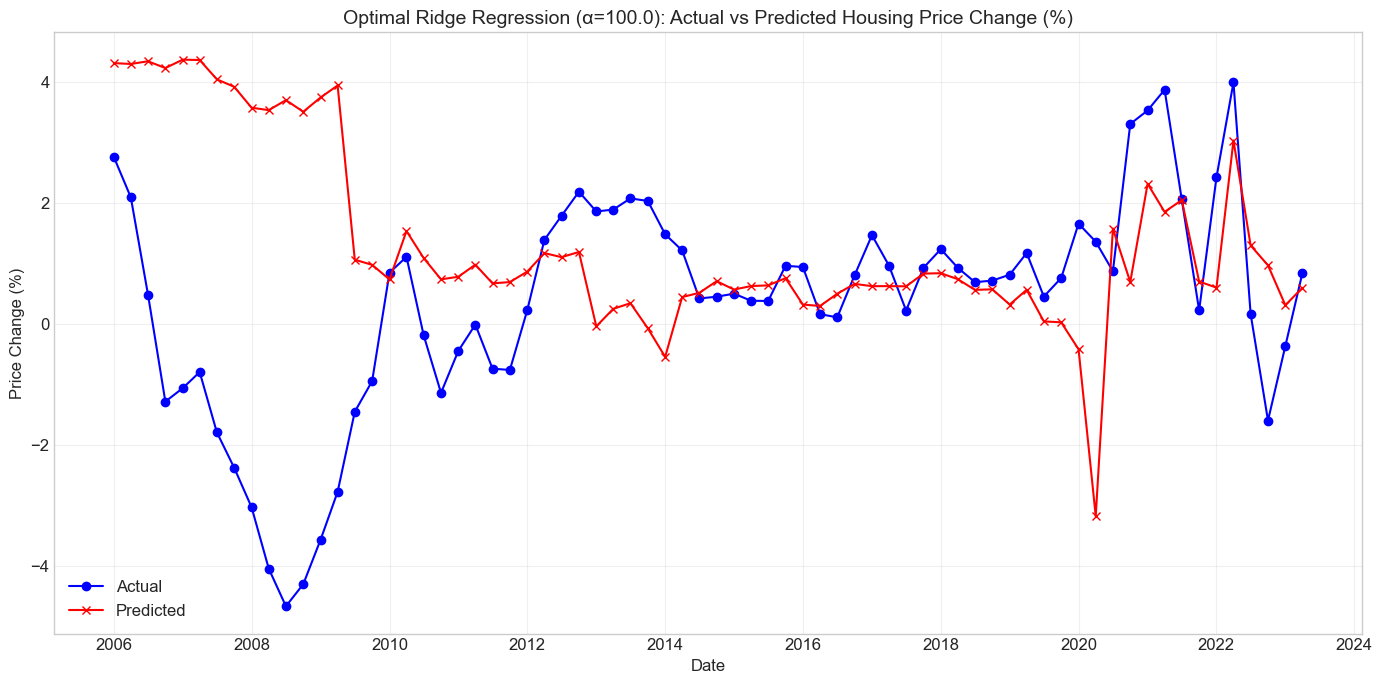

Optimal Ridge Model (α=100.0) Cross-Validation Performance:
RMSE: 2.9499
MAE: 1.9198
R²: -1.7108

Actual values range: -4.66 to 4.00
Predicted values range: -3.17 to 4.37

In-sample performance (α=100.0):
RMSE: 1.4728
MAE: 1.1495
R²: 0.5705


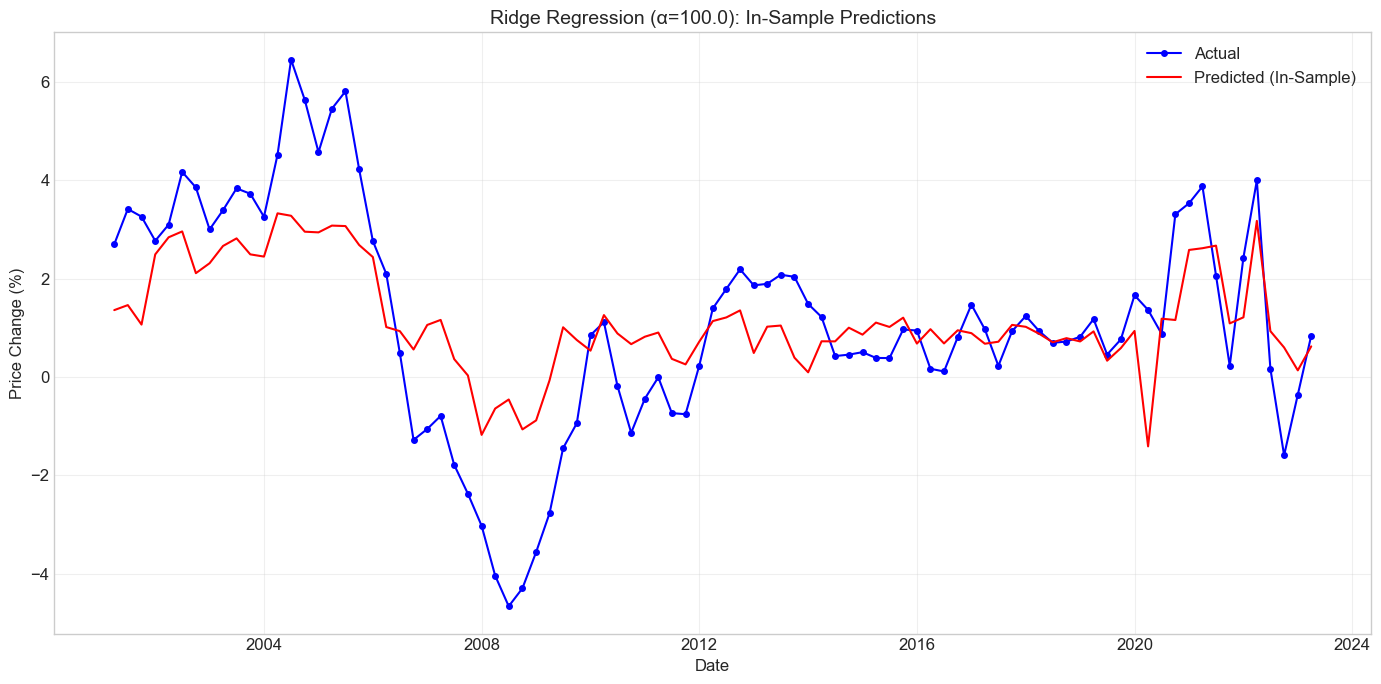

In [38]:
# Generate predictions using the optimal alpha value (100.0)
optimal_ridge = Ridge(alpha=100.0)

# Function to generate predictions with time series cross-validation
def generate_cv_predictions(model, X, y, cv=5):
    """Generate predictions using time series cross-validation"""
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # For storing predictions
    all_predictions = []
    all_test_indices = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Store predictions and indices
        for i, idx in enumerate(test_idx):
            all_predictions.append(y_pred[i])
            all_test_indices.append(idx)
    
    # Create a DataFrame with results
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': y.iloc[all_test_indices].values,
        'Predicted': all_predictions
    }).sort_values('Index')
    
    return results_df

# Generate predictions with optimal alpha
results_optimal_ridge = generate_cv_predictions(optimal_ridge, X_scaled_df, y, cv=5)

# Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(results_optimal_ridge['Index'], results_optimal_ridge['Actual'], marker='o', label='Actual', color='blue')
plt.plot(results_optimal_ridge['Index'], results_optimal_ridge['Predicted'], marker='x', label='Predicted', color='red')
plt.title('Optimal Ridge Regression (α=100.0): Actual vs Predicted Housing Price Change (%)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted']))
r2 = r2_score(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted'])
mae = mean_absolute_error(results_optimal_ridge['Actual'], results_optimal_ridge['Predicted'])

print(f"Optimal Ridge Model (α=100.0) Cross-Validation Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Check range of predictions vs actuals
print(f"\nActual values range: {results_optimal_ridge['Actual'].min():.2f} to {results_optimal_ridge['Actual'].max():.2f}")
print(f"Predicted values range: {results_optimal_ridge['Predicted'].min():.2f} to {results_optimal_ridge['Predicted'].max():.2f}")

# Let's also train on all data and show in-sample performance (for comparison)
final_model = Ridge(alpha=100.0)
final_model.fit(X_scaled, y)
in_sample_preds = final_model.predict(X_scaled)

in_sample_rmse = np.sqrt(mean_squared_error(y, in_sample_preds))
in_sample_r2 = r2_score(y, in_sample_preds)
in_sample_mae = mean_absolute_error(y, in_sample_preds)

print(f"\nIn-sample performance (α=100.0):")
print(f"RMSE: {in_sample_rmse:.4f}")
print(f"MAE: {in_sample_mae:.4f}")
print(f"R²: {in_sample_r2:.4f}")

# Plot in-sample predictions
plt.figure(figsize=(14, 7))
plt.plot(y.index, y, marker='o', markersize=4, label='Actual', color='blue')
plt.plot(y.index, in_sample_preds, marker='', linestyle='-', label='Predicted (In-Sample)', color='red')
plt.title('Ridge Regression (α=100.0): In-Sample Predictions', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Change (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()